In [1]:
import h5py
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import numpyro
import numpyro.distributions as dist
import pandas
import pandas as pd
from chainconsumer import Chain, ChainConsumer, PlotConfig
from numpyro.infer import MCMC, NUTS

In [2]:
sim = "m12i"
sim_dir = "/Users/z5114326/Documents/simulations/"

in_flag = True  # True for in-situ, False for ex-situ
snapz0 = 600

In [3]:
ghost_file = f"{sim_dir}{sim}/{sim}_ghosts.hdf5"
ghost_data = h5py.File(ghost_file, "r")

public_snapshot_file = sim_dir + "snapshot_times_public.txt"
pub_data = pd.read_table(public_snapshot_file, comment="#", header=None, sep=r"\s+")
pub_data.columns = [
    "index",
    "scale_factor",
    "redshift",
    "time_Gyr",
    "lookback_time_Gyr",
    "time_width_Myr",
]
timez0 = np.array(pub_data["time_Gyr"])[-1]
timez0

np.float64(13.798746883)

In [4]:
prop_dict = {"mfor": np.array([]), "mz0": np.array([]), "pz0": np.array([]), "age": np.array([])}

for it_id in ghost_data.keys():
    src_dat = ghost_data[it_id]["source"]

    smsk = src_dat["s_flag"][()].astype(bool)
    if in_flag:
        amsk = src_dat["grpid"][()] == 0
    else:
        amsk = src_dat["grpid"][()] != 0
    msk = smsk & amsk

    mfor = 10 ** src_dat["logm_tfor"][msk]
    mz0 = 10 ** src_dat["logm_tz0"][msk]
    pz0 = src_dat["torb_600"][msk]
    age = timez0 - src_dat["tfor"][msk]

    prop_dict["mfor"] = np.append(prop_dict["mfor"], mfor)
    prop_dict["mz0"] = np.append(prop_dict["mz0"], mz0)
    prop_dict["pz0"] = np.append(prop_dict["pz0"], pz0)
    prop_dict["age"] = np.append(prop_dict["age"], age)

In [5]:
def gc_hierarchical_model(mz0, age, pz0):
    """
    Hierarchical GC model with latent formation masses.

    Parameters
    ----------
    mz0 : array
        Present-day GC mass (linear units)
    age : array
        GC age (linear units)
    pz0 : array
        Environmental parameter (linear units)

    All inputs must be positive and have the same length.
    """

    # --------------------------------------------------
    # Log-transform observables
    # --------------------------------------------------
    log_mz0 = jnp.log10(mz0)
    log_age = jnp.log10(age)
    log_pz0 = jnp.log10(pz0)

    N = len(log_mz0)

    # --------------------------------------------------
    # Population-level prior on formation masses
    # --------------------------------------------------
    mu_for = numpyro.sample("mu_for", dist.Normal(6.0, 1.0))
    sigma_for = numpyro.sample("sigma_for", dist.HalfNormal(1.0))

    with numpyro.plate("clusters", N):
        log_mfor = numpyro.sample("log_mfor", dist.Normal(mu_for, sigma_for))

    # --------------------------------------------------
    # Mass-loss model parameters
    # --------------------------------------------------
    a = numpyro.sample("a", dist.Normal(0.0, 1.0))  # age dependence
    b = numpyro.sample("b", dist.Normal(0.0, 1.0))  # environment dependence
    c = numpyro.sample("c", dist.Normal(0.0, 1.0))  # normalization

    sigma_int = numpyro.sample("sigma_int", dist.HalfNormal(1.0))

    # --------------------------------------------------
    # Forward (generative) model
    # --------------------------------------------------
    mu_loss = a * log_age + b * log_pz0 + c
    log_mz0_model = log_mfor - mu_loss

    # --------------------------------------------------
    # Likelihood
    # --------------------------------------------------
    with numpyro.plate("clusters", N):
        numpyro.sample("mz0_obs", dist.Normal(log_mz0_model, sigma_int), obs=log_mz0)


In [6]:
# ---------------------------------------
# Set up HMC
# ---------------------------------------
nuts_kernel = NUTS(gc_hierarchical_model)
mcmc = MCMC(
    nuts_kernel,
    num_warmup=1000,
    num_samples=10000,
)

# ---------------------------------------
# Run inference
# ---------------------------------------
rng_key = jax.random.PRNGKey(0)

mcmc.run(
    rng_key,
    mz0=prop_dict["mz0"],
    age=prop_dict["age"],
    pz0=prop_dict["pz0"],
)

# ---------------------------------------
# Posterior samples
# ---------------------------------------
posterior = mcmc.get_samples()

# ---------------------------------------
# Summary
# ---------------------------------------
mcmc.print_summary()


sample: 100%|██████████| 11000/11000 [06:13<00:00, 29.45it/s, 255 steps of size 1.96e-02. acc. prob=0.94]



                     mean       std    median      5.0%     95.0%     n_eff     r_hat
              a      0.22      0.11      0.22      0.05      0.41   4470.61      1.00
              b      0.46      0.02      0.46      0.43      0.48   5495.59      1.00
              c     -4.48      0.79     -4.41     -5.65     -3.06      3.10      2.45
    log_mfor[0]      1.45      0.85      1.42     -0.07      2.74      3.38      2.23
    log_mfor[1]      1.55      0.84      1.54      0.11      2.91      3.38      2.21
    log_mfor[2]      1.71      0.83      1.75      0.39      3.12      3.36      2.21
    log_mfor[3]      1.95      0.83      2.02      0.57      3.27      3.49      2.10
    log_mfor[4]      1.61      0.84      1.61      0.23      2.99      3.36      2.23
    log_mfor[5]      1.54      0.84      1.52      0.09      2.88      3.36      2.23
    log_mfor[6]      0.55      1.02      0.47     -1.03      2.28      4.37      1.88
    log_mfor[7]      2.08      0.82      2.14      0.

In [ ]:
posterior[.keys()]

dict_keys(['a', 'b', 'c', 'log_mfor', 'mu_for', 'sigma_for', 'sigma_int'])

In [18]:
df = pd.DataFrame(
    {
        "a": posterior["a"],
        "b": posterior["b"],
        "c": posterior["c"],
        # "log_mfor": posterior["log_mfor"],
    }
)


Parameter c in chain Forward model (simulation-calibrated) is not constrained


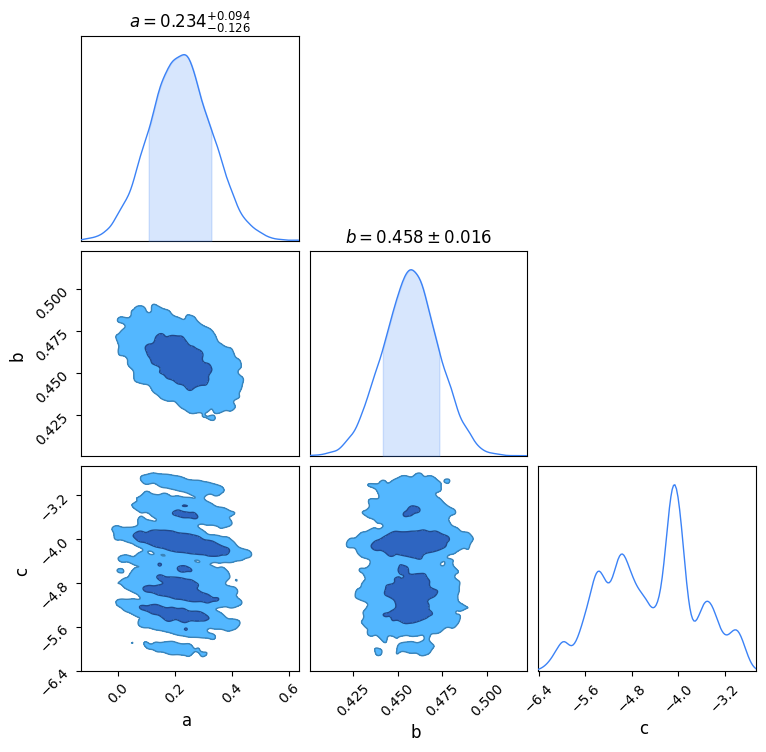

In [19]:
C = ChainConsumer()

C.add_chain(Chain(samples=df, name="Forward model (simulation-calibrated)"))

C.set_plot_config(
    PlotConfig(
        diagonal_tick_labels=True,
        shade=True,
        shade_alpha=0.4,
        sigma2d=True,
        flip=False,
    )
)

fig = C.plotter.plot(figsize=(8, 8))